In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# make a dataset
X , y = make_regression(n_samples = 100 , n_features = 1 , n_informative = 1 , n_targets = 1 , noise = 20 , random_state = 13)

In [3]:
# train test split 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

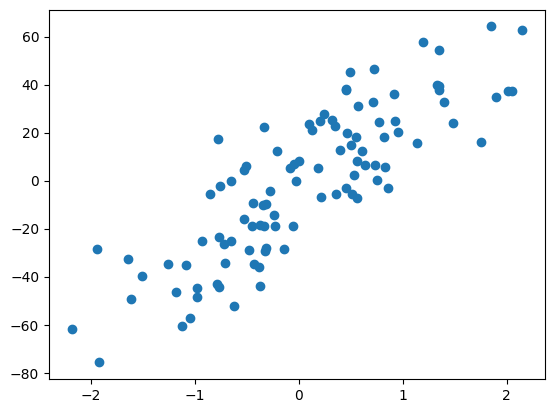

In [4]:
# plot X and y 
plt.scatter(X , y) 
plt.show()

In [5]:
# Fit a Linear Regression model 
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train , y_train)

print(f"Coef: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")

Coef: [28.12597332]
Intercept: -2.2710144261783825


In [6]:
from sklearn.metrics import accuracy_score , r2_score , mean_squared_error

In [10]:
# Take different values of alpha and see the Lasso Model 
alphas = [0 , 1 , 5 , 10 , 30]

for alpha in alphas: 
    L = Lasso(alpha = alpha)
    L.fit(X_train , y_train) 
    y_pred = L.predict(X_test)
    
    print(f"For Alpha: {alpha}")
    print(f"Coefs: {L.coef_}")
    print(f"intercept: {L.intercept_}")
    print(f"r2_score = {r2_score(y_test , y_pred)}")
    # print(f"accuracy_score = {accuracy_score(y_test , y_pred)}")  
    print(f"mse = {mean_squared_error(y_test , y_pred)}")
    print("-----------------------------------------------------------")

For Alpha: 0
Coefs: [28.12597332]
intercept: -2.2710144261783825
r2_score = 0.6345158782661013
mse = 212.1980691451566
-----------------------------------------------------------
For Alpha: 1
Coefs: [27.06882916]
intercept: -2.217473493693001
r2_score = 0.638156461427544
mse = 210.08436660247003
-----------------------------------------------------------
For Alpha: 5
Coefs: [22.84025252]
intercept: -2.0033097637514765
r2_score = 0.6312076436614903
mse = 214.1188119452741
-----------------------------------------------------------
For Alpha: 10
Coefs: [17.55453172]
intercept: -1.7356051013245706
r2_score = 0.5741215330273175
mse = 247.2626935292677
-----------------------------------------------------------
For Alpha: 30
Coefs: [0.]
intercept: -0.8465248480116216
r2_score = -0.0013512390389767148
mse = 581.3790171023811
-----------------------------------------------------------


Note: As we increase the value of alpha , we shrink the coefficents more.Move towards zero

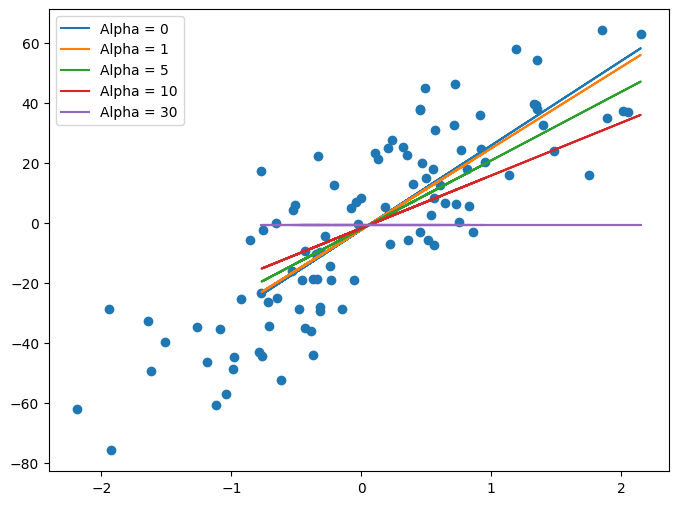

In [12]:
alphas = [0 , 1 , 5 , 10 , 30]

plt.figure(figsize = (8 , 6))

plt.scatter(X , y) 

for alpha in alphas: 
    L = Lasso(alpha = alpha)
    L.fit(X_train , y_train) 
    y_pred = L.predict(X_test)

    plt.plot(X_test , y_pred , label = f'Alpha = {alpha}')

plt.legend()
plt.show()

<h4 style = "color:red;">Observation:</h4>

- As value of alpha is increasing slope is decreasing and model tends to underfitting.
- Also we can see that for alpha = 30 , slope(coef) are zero. For Lasso value of coef can be zero which was not possible for Ridge

<h2 style = "color:green;">For Polynomial Data</h2>

In [22]:
m = 100
x1 = 5 * np.random.rand(m , 1)
x2 = 0.7 * x1**1.54 - 2*x1 + 3 + np.random.rand(m , 1) 

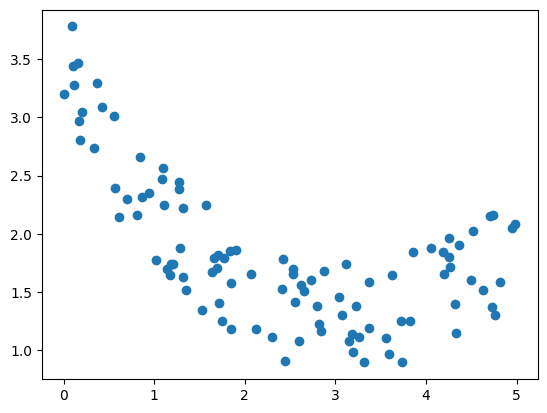

In [23]:
plt.scatter(x1 , x2)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [30]:
def get_preds_lasso(x1 , x2 , alpha): 
    model = Pipeline([
        ('poly_feat' , PolynomialFeatures(degree = 16)) , 
        ('lasso' , Lasso(alpha = alpha))
    ])

    model.fit(x1 , x2) 
    return model.predict(x1)

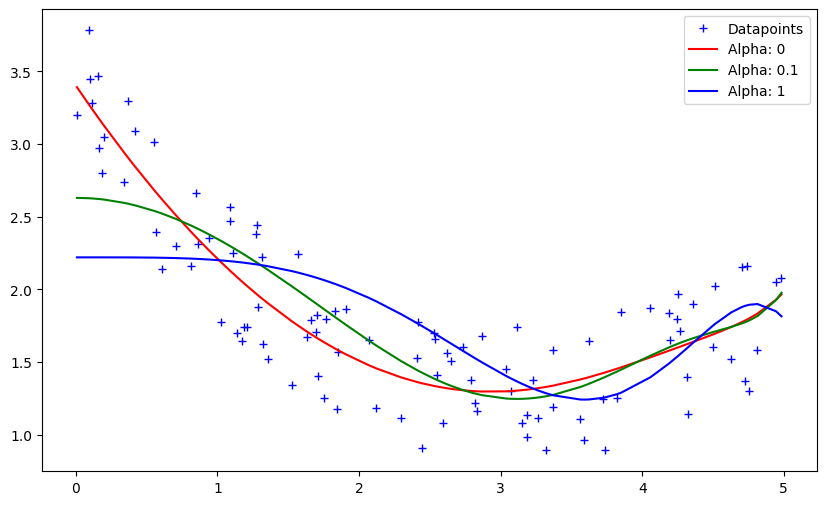

In [31]:
alphas = [0 , 0.1 , 1]
cs = ['r' , 'g' , 'b']

plt.figure(figsize = (10 , 6))
plt.plot(x1 , x2 , 'b+' , label = 'Datapoints')

for alpha , c in zip(alphas , cs): 
    preds = get_preds_lasso(x1 , x2 , alpha)

    plt.plot(sorted(x1[: , 0]) , preds[np.argsort(x1[: , 0])] , c , label = "Alpha: {}".format(alpha))

plt.legend()
plt.show()

### Observations: 

- RedLine is normal regression which tends to overfitting
- blueLine tends to underfitting and green line is the perfect generalized line 